In [70]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [71]:
torch.manual_seed(42)

In [72]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [73]:
df = pd.read_csv('https://raw.githubusercontent.com/Niaj-Morshed-Niloy/Datasets/refs/heads/main/fmnist_small.csv')
# df = pd.read_csv('/content/fashion-mnist_train.csv')
df.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [74]:
df.shape

(6000, 785)

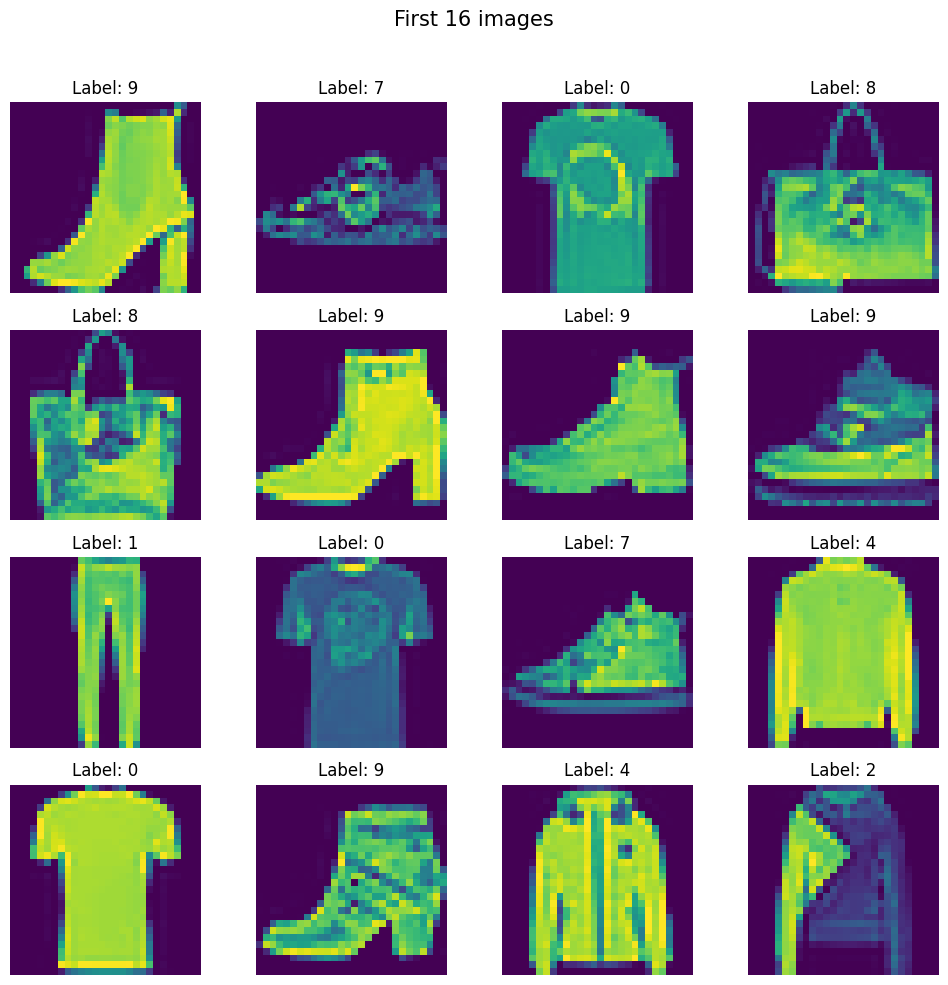

In [75]:
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 images", fontsize=15)

for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f'Label: {df.iloc[i,0]}')

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


In [76]:
X=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
X_train = X_train/255.0
X_test = X_test/255.0

In [79]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):

    self.features=torch.tensor(features,dtype=torch.float32)
    self.labels=torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)
  def __getitem__(self,index):
    return self.features[index],self.labels[index]


In [80]:
train_dataset=CustomDataset(X_train,y_train)
test_dataset=CustomDataset(X_test,y_test)

In [81]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [82]:
len(train_loader)

150

In [83]:
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.model=nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self,x):
    return self.model(x)

In [84]:
learning_rate=0.1
epochs=100

model=MyNN(X_train.shape[1])   #instatiate the model
model=model.to(device)

criterion=nn.CrossEntropyLoss()

optimizer=optim.SGD(model.parameters(),lr=learning_rate)

In [85]:
for epoch in range(epochs):
  total_epoch_loss=0
  for batch_features,batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # backward pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 1.3216368587811789
Epoch: 2 , Loss: 0.779336541891098
Epoch: 3 , Loss: 0.6427524608373641
Epoch: 4 , Loss: 0.5751657414436341
Epoch: 5 , Loss: 0.5278772541880608
Epoch: 6 , Loss: 0.49531100074450174
Epoch: 7 , Loss: 0.46192684868971506
Epoch: 8 , Loss: 0.4355265040695667
Epoch: 9 , Loss: 0.41890643616517387
Epoch: 10 , Loss: 0.39741520086924237
Epoch: 11 , Loss: 0.38665723502635957
Epoch: 12 , Loss: 0.37127780785163245
Epoch: 13 , Loss: 0.34902072985967
Epoch: 14 , Loss: 0.3476298343638579
Epoch: 15 , Loss: 0.315855147143205
Epoch: 16 , Loss: 0.31195787360270816
Epoch: 17 , Loss: 0.2958236853778362
Epoch: 18 , Loss: 0.2882651568452517
Epoch: 19 , Loss: 0.2712535865108172
Epoch: 20 , Loss: 0.2599384474754334
Epoch: 21 , Loss: 0.2577110414206982
Epoch: 22 , Loss: 0.24670669116079808
Epoch: 23 , Loss: 0.23920624203979968
Epoch: 24 , Loss: 0.22601549635330836
Epoch: 25 , Loss: 0.2235869560142358
Epoch: 26 , Loss: 0.21268803268671035
Epoch: 27 , Loss: 0.21945507449408372
Ep

In [86]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [87]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.8241666666666667


In [88]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.99875
